# Proyecto Final Big Data: `PokeIA`
**Estudiantes**: Ignacio Códova, Joaquín López, Vicente Silva

**Profesor**: Miguel Cárcamo

---

## 1. Pequeña introducción y preámbulo


Para el proyecto final del curso nos propusimos desarrollar un modelo de red neuronal aplicado a una tarea quizás un poco fuera de los cánones convencionales de la carrera o de los otros proyectos planteados; entrenar una IA capaz de jugar al Pokemon Rojo de GameBoy. Para ello:

- Implementamos un entrenador basado en el algoritmo DQN (Deep Q-Network) utilizando la librería PyBoy, que permite interactuar con el emulador del juego de forma programática.

- Diseñamos un sistema de recompensas que incentiva la exploración de nuevas áreas, optimizamos la detección de combates y añadimos mecanismos antibloqueo para evitar que el personaje controlado por la IA quede atrapado en zonas del mapa (como esquinas o dentro de algunas casas), problema frecuente en versiones anteriores.

- Dado que no contábamos con un computador dedicado para entrenar la IA indefinidamente, incorporamos funciones que aceleran el ingreso al juego, como saltar la introducción y guiar el proceso de nombrar al personaje, evitando así que el modelo pierda tiempo valioso intentando resolver estas etapas de forma no supervisada.

El uso de la IA en un juego ofrece una plataforma ideal para explorar y validar algoritmos de aprendizaje por refuerzo (RL) en entornos simulados y controlados. En particular, Pokémon Rojo representa un reto relativamente moderado (teniendo el computador y tiempos necesarios) al combinar:

- Exploración de mapas complejos.

- Interacción mediante diálogos.

- Diversas acciones y decisiones posibles que dependen del contexto.

Para poder llevar a cabo el proyecto se utilizó PyBoy, un emulador de GameBoy escrito en Python, que permite:

- Controlar la ejecución del juego mediante scripts.

- Acceder a la memoria interna (WRAM).

- Extraer imágenes en tiempo real para alimentar la red neuronal y ajustar las políticas de acción del modelo.

---

Esto siendo a grandes rasgos nuestro proyecto, el cuál describimos a continuación en detalle y con mayor profundidad en cada una de las celdas para que se haga fácil comprender el por qué aplicamos cada cosa, qué es cada cosa (muy importante) y cómo es que funciona todo dentro de la lógica del poyecto.

## 2. Importación de Librerías
### *¡¡¡y algunos prerrequsitos importantes!!!*

En la celda de abajo están los **prerequisitos instalables** necesarios para correr el código.

**NO OLVDAR TENER EN EL DIRECTORIO LA ROM DEL JUEGO**

el codigo está hecho para buscar la rom por el nombre de `POKEMON_RED.gb` así que asegurarse de tenerla disponible por ese nombre en el directorio.

In [ ]:
!pip install numpy tensorflow opencv-python matplotlib pyboy

In [9]:
import os                               # para crear carpetas, manejar rutas, guardar archivos
import numpy as np                      # operaciones numéricas y matrices
import tensorflow as tf                 # framework del deep learning
from tensorflow import keras            # para definir la arquitectura de la red neuronal
from tensorflow.keras import layers     # capas individuales de la red neuronal
import cv2                              # del opencv: procesamiento de imágenes (pasar imagenes a blanco y negro, resize, etc)
from PIL import Image                   # para guardar capturas de pantalla como PNG
from collections import deque           # estructura eficiente para apilar frames
from pyboy import PyBoy                 # núcleo del emulador de gameboy
from pyboy.utils import WindowEvent     # interfaz para ineteractuar con el juego
import random                           # para selección de acciones (e-greedy) y muestreo aleatorio de memoria

- Estos imports cubren todo el pipeline: lectura de imagen $\rightarrow$ procesamiento $\rightarrow$ predicción $\rightarrow$ acción $\rightarrow$ guardado de métricas.

- Elegimos TensorFlow/Keras por su simplicidad (en comparasión a cosas como torch) y compatibilidad.

- Usamos PyBoy por su acceso bajo nivel a memoria y control de inputs, ideal para RL.

## 3. Clase `DQN`: Deep Q-Network

El `DQN` es un algoritmo de aprendizaje por refuerzo profundo que combina:
- La *Q-Learning tradicional* $\rightarrow$ un método para aprender la política óptima de acciones usando una función de valor Q.
- Con una *Red Neuronal Profunda (Deep Neural Network)* $\rightarrow$ para aproximar esa función Q cuando el espacio de estados es demasiado grande para tablas.

*Ojo!* que hay también transfondo histórico (que encontramos investigando para este proyecto) con la arquitectura original DQN de DeepMind para Atari.

### Esto nos resuelve que:

En entornos complejos (como en nuestro caso con imágenes del juego), es imposible guardar todos los estados en una tabla de Q-Learning tradicional.  
Para resolverlo, se usa una **red neuronal** como **aproximador** de la función $Q(s,a)$ (que representa la función de valor de acción, que es la que estima la recompensa esperada acumulada que se obtendrá al tomar la acción `a` en el estado `s` y seguir la política óptima a partir de ahí).

### Esto sigue una estructura del tipo:

- La red recibe como entrada la representación del estado (imagen apilada de frames).
- La salida es un vector (un Q-valor para cada acción posible).
- Durante el entrenamiento, se ajustan los pesos para minimizar la diferencia entre el Q predicho y el Q objetivo (usando la ecuación de Bellman que define cómo actualizar la estimación del valor usando recompensas y estimados futuros).
- Se utiliza un Replay Buffer (almacena experiencias pasadas y permite entrenar con muestras aleatorias para mejorar la estabilidad) para romper la correlación temporal y estabilizar el entrenamiento.
- Se copia periódicamente la red a una Target Network (mantiene una copia congelada de los pesos para evitar bucles de retroalimentación inestables) para que los Q objetivos sean más estables y el aprendizaje sea más robusto.

### Y el DQN lo usamos porque:

Es un estandar ya más o menos probado que funciona perfectamente bien con el tipo de aproximación que buscamos con las imágenes del juego, y además, si se usó para resolver juegos de Atari usando solo pixeles como entrada y un conjunto discreto de acciones (igual que como planeamos usarlo con Pokemon Rojo, que viéndolo así como así no dista tanto de un juego de Atari) es de esperar que rinda frutos en un proyecto como el nuestro.

### Entonces, para ir cerrando esta sección: 

La red `DQN` se implementa como una subclase de `tf.keras.Model`.  
Este patrón es flexible, mantiene compatibilidad con TensorFlow 2.x y permite usar `GradientTape` para entrenamiento personalizado.

**Por qué se estructura así:**
- 3 capas convolucionales (`Conv2D`) para extraer características espaciales de las imágenes.
- Capa *Flatten* para transformar mapas de activación en un vector 1D.
- Capa *Dense(512)* para aprendizaje no lineal de alto nivel.
- Capa final `Dense(num_actions)` para producir los valores Q (un valor por acción disponible).

In [3]:
class DQN(keras.Model):
    def __init__(self, num_actions):
        super(DQN, self).__init__()  # para inicializar la clase base tf.keras.Model

        # 1era capa convolucional:
        # filtros grandes, hacemos un stride mas o menos grande para la reducción de dimensionalidad inicial
        self.conv1 = layers.Conv2D(32, 8, strides=4, activation='relu')

        # 2nda capa convolucional:
        # filtros medianos, stride más chica para captar los detalles medianos
        self.conv2 = layers.Conv2D(64, 4, strides=2, activation='relu')

        # 3era capa convolucional:
        # filtros más pequeños, stride 1 (o sea mínimo) para capturar detalles más finitos
        self.conv3 = layers.Conv2D(64, 3, strides=1, activation='relu')

        # capa flatten para pasar de 2D a 1D
        self.flat  = layers.Flatten()

        # capa densa intermedia para aprender representaciones abstractas
        self.dense = layers.Dense(512, activation='relu')

        # capa de salida produce un q-valor para cada acción posible
        self.out   = layers.Dense(num_actions)


    def call(self, x):
        # para escalar imágenes de [0,255] a [0,1] para entrenamiento estable
        x = tf.cast(x, tf.float32) / 255.0
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.flat(x)
        x = self.dense(x)
        return self.out(x)  # vector de q-valores

## 4. Clase `ReplayBuffer`

Esta clase almacena transiciones (estado, acción, recompensa, estado siguiente, `done`).

¿Por qué se usa?
- Rompe la correlación temporal de los datos secuenciales.
- Permite reutilizar experiencias pasadas.
- Hace posible un entrenamiento **más estable** y eficiente.

Implementa:
- Un buffer fijo con sobrescritura circular (`ptr`).
- Un método `store` para guardar experiencias.
- Un método `sample` para extraer mini-lotes aleatorios.

In [4]:
class ReplayBuffer:
    def __init__(self, size, input_shape):
        self.size = size         # tamaño máximo del buffer
        self.ptr = 0             # puntero (pues el ptr) para sobrescribir
        self.count = 0           # número real de muestras almacenadas

        # estados apilados (frames)
        self.obs = np.zeros((size, *input_shape), dtype=np.uint8)
        self.actions = np.zeros(size, dtype=np.int32)
        self.rewards = np.zeros(size, dtype=np.float32)
        self.dones = np.zeros(size, dtype=bool)

    def store(self, obs, action, reward, done):
        # guarda una transición en la posición actual
        self.obs[self.ptr] = obs
        self.actions[self.ptr] = action
        self.rewards[self.ptr] = reward
        self.dones[self.ptr] = done

        # avanza el puntero de forma circular
        self.ptr = (self.ptr + 1) % self.size
        self.count = min(self.count + 1, self.size)

    def sample(self, batch_size):
        # muestra índices aleatorios del buffer (excepto el último)
        idx = np.random.choice(self.count - 1, batch_size, replace=False)
        return (
            self.obs[idx],
            self.actions[idx],
            self.rewards[idx],
            self.obs[idx + 1],  # estado siguiente
            self.dones[idx]
        )

## 5. Clase `PokemonAITrainer`: Entrenador Principal
### *"...yo quiero ser siempre el mejor, mejor que nadie más.. tun, tun, tu, tun..."*

### ¿Qué hace nuestro entrenador pokemon?:
- Configura la emulación `PyBoy` en modo `null` (headless).
- Define hiperparámetros RL (`gamma`, `epsilon`, `batch_size`...).
- Controla offsets de memoria para monitorear el estado real del juego.
- Calcula recompensas: exploración, diálogos, milestones.
- Ejecuta el bucle principal de entrenamiento.
- Guarda capturas periódicas y pesos intermedios.

**IMPORTANTE:** 

Quisimos separar el trainer para poder explicar de forma más fragemtada (como lo veníamos haciendo hasta ahora) para poder explicar en forma más detallada sección dentro del trainer pero no se pude fragmentar la calse trainer sino no funciona, ya que (igual de forma obvia) no encontraría las funciones si lo fragmentamos. Todos sus métodos (`__init__`, `initialize_game`, `train`, etc.) deben estar indentados **dentro de la clase** para funcionar correctamente, sino muere.

### Ayudínes:
Dentro del entrenador Pokemon pusimos algunas ayuditas para que evitar que el modelo se quede atasacado en cosas como el teclado del inicio mientras pone su nombre, ya que buscamos que caiga dentro del "juego de verdad" lo antes posible.
Un ejemplo de estas ayudas es el método `skip_intro`, el cual se explica mejor en los comentarios del código siguiente.

In [5]:
class PokemonAITrainer:
    def __init__(self, rom_path="POKEMON_RED.gb", screenshot_interval=100):
        """
        se inicializan los parámetros base del agente: rutas, imágenes, acciones, red, buffer, offsets WRAM y flags
        """
        self.rom_path = rom_path
        self.screenshot_interval = screenshot_interval
        os.makedirs("pantallzosv7", exist_ok=True) # decidimos dejar el v7 como legado de todas las versiones que tuvimos que hacer para que funcionase bien

        # tamaño de imagen final y número de frames apilados (el stack)
        self.frame_shape = (84, 84)
        self.frame_stack = 4
        self.input_shape = (*self.frame_shape, self.frame_stack)

        # define acciones disponibles (flechas + botones A y B)
        self.press_actions = [
            WindowEvent.PRESS_ARROW_UP, WindowEvent.PRESS_ARROW_DOWN,
            WindowEvent.PRESS_ARROW_LEFT, WindowEvent.PRESS_ARROW_RIGHT,
            WindowEvent.PRESS_BUTTON_A, WindowEvent.PRESS_BUTTON_B
        ]
        self.release_actions = [
            WindowEvent.RELEASE_ARROW_UP, WindowEvent.RELEASE_ARROW_DOWN,
            WindowEvent.RELEASE_ARROW_LEFT, WindowEvent.RELEASE_ARROW_RIGHT,
            WindowEvent.RELEASE_BUTTON_A, WindowEvent.RELEASE_BUTTON_B
        ]
        self.num_actions = len(self.press_actions)

        # los hiperparámetros de aprendizaje por refuerzo
        self.lr = 1e-4
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.999
        self.batch_size = 32
        self.update_target_every = 1000
        self.step_count = 0

        # buffer de experiencia
        self.replay = ReplayBuffer(20000, self.input_shape)

        # los offsets WRAM para monitorear bloque, mapa, game over
        self.addr_block_y = 0xD363
        self.addr_block_x = 0xD364
        self.addr_tileset_id = 0xD367
        self.addr_game_over = 0xD1F6

        # flags de diálogo y las "milestones" (para recompensas adicionales)
        self.dialogue_addrs = [0xD3E8, 0xD3E9, 0xD3EA]
        self.prev_dialogue = {addr: 0 for addr in self.dialogue_addrs}

        self.milestone_addrs = [0xD300, 0xD301]
        self.prev_milestone = {addr: 0 for addr in self.milestone_addrs}

        self.visited_blocks = set()
        self.visited_regions = set()
        self.initial_map_id = None

        # la red principal y red objetivo
        self.model = DQN(self.num_actions)
        self.target_model = DQN(self.num_actions)
        self.optimizer = keras.optimizers.Adam(self.lr)
        self.loss_fn = keras.losses.Huber()

        # métricas para la posterior evaluación del modelo
        self.losses = []   # guarda cada loss calculado en train_step
        self.rewards = []  # guarda reward total por episodio
        self.actions_taken = []  # guarda acciones elegidas

    def skip_intro(self):
        """
        hace que se omita la intro del juego pulsando START y A muchas veces, así no se nos queda atrapado en el inicio
        """
        for _ in range(25):
            self.pyboy.send_input(WindowEvent.PRESS_BUTTON_START)
            self.pyboy.tick()
            self.pyboy.send_input(WindowEvent.RELEASE_BUTTON_START)
            self.pyboy.tick()
        for _ in range(10000):
            self.pyboy.send_input(WindowEvent.PRESS_BUTTON_A)
            self.pyboy.tick()
            self.pyboy.send_input(WindowEvent.RELEASE_BUTTON_A)
            self.pyboy.tick()

    def initialize_game(self):
        """
        se inicia paynoy en modo 'null' (headless). reinicia flags, mapa, buffer de frames
        """
        if hasattr(self, 'pyboy') and self.pyboy:
            self.pyboy.stop()
        self.pyboy = PyBoy(self.rom_path, window="null")
        self.pyboy.set_emulation_speed(0)
        self.pyboy.game_wrapper.start_game()
        self.skip_intro()

        map_id = int(self.pyboy.memory[self.addr_tileset_id])
        self.initial_map_id = map_id
        self.visited_regions = {map_id}
        self.visited_blocks.clear()

        for addr in self.dialogue_addrs:
            self.prev_dialogue[addr] = 0
        for addr in self.milestone_addrs:
            self.prev_milestone[addr] = 0

        for _ in range(random.randint(0, 10)):
            self.pyboy.tick()

        first = self.get_processed_frame()
        self.frame_buffer = deque([first]*self.frame_stack, maxlen=self.frame_stack)

    def get_processed_frame(self):
        """
        hace una caputra del frame actual, convierte a blanco y negro para que no saque la escala de colores media verde
        de la versión de gameboy color, redimensiona.
        """
        raw = self.pyboy.screen.ndarray
        gray = cv2.cvtColor(raw, cv2.COLOR_RGB2GRAY)
        return cv2.resize(gray, self.frame_shape, interpolation=cv2.INTER_AREA)

    def get_state(self):
        """
        devuelve un stack de frames para dar contexto temporal.
        """
        frame = self.get_processed_frame()
        self.frame_buffer.append(frame)
        return np.stack(self.frame_buffer, axis=-1)

    def execute(self, action_idx):
        """
        envía una acción al emulador que presiona y libera botón/flecha.
        """
        self.pyboy.send_input(self.press_actions[action_idx])
        for _ in range(4): self.pyboy.tick()
        self.pyboy.send_input(self.release_actions[action_idx])
        for _ in range(4): self.pyboy.tick()

    @tf.function
    def train_step(self, obs, acts, rews, next_obs, dones):
        """
        paso de entrenamiento: calcula Q, bellman target, loss huber, aplica gradientes
        """
        next_q = self.model(next_obs, training=False)
        next_act = tf.argmax(next_q, axis=1, output_type=tf.int32)
        next_q_target = self.target_model(next_obs, training=False)
        idx = tf.stack([tf.range(self.batch_size), next_act], axis=1)
        target = tf.where(dones, rews, rews + self.gamma * tf.gather_nd(next_q_target, idx))

        with tf.GradientTape() as tape:
            q_vals = self.model(obs, training=True)
            chosen = tf.gather_nd(q_vals, tf.stack([tf.range(self.batch_size), acts], axis=1))
            loss = self.loss_fn(target, chosen)

        grads = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
        return loss

    def train(self, episodes=500, max_steps=5000): #original episodes=500, max_steps=5000
        """
        el bucle de entrenamiento con recompensas combinadas, replay buffer y target network
        """
        for ep in range(episodes):
            self.epsilon = 1.0
            self.initialize_game()
            state = self.get_state()
            total_reward = 0.0
            steps = 0
            done = False

            while not done and steps < max_steps:
                action = self.choose_action(state)
                # guarda la acción elegida en cada paso para análisis estadístico
                self.actions_taken.append(action)
                self.execute(action)

                if steps % self.screenshot_interval == 0:
                    img = Image.fromarray(self.pyboy.screen.ndarray)
                    img.save(f"pantallzosv7/ep{ep:03d}_paso{steps:04d}.png")

                done = int(self.pyboy.memory[self.addr_game_over]) == 1
                next_state = self.get_state()

                diff = np.mean(np.abs(next_state[..., -1].astype(np.float32) - state[..., -1].astype(np.float32)))
                base_reward = 1.0 if diff > 1.0 else diff * 0.1

                by, bx = int(self.pyboy.memory[self.addr_block_y]), int(self.pyboy.memory[self.addr_block_x])
                block_id = (int(self.pyboy.memory[self.addr_tileset_id]), bx, by)
                explor_bonus = 1.0 if block_id not in self.visited_blocks else 0.0
                self.visited_blocks.add(block_id)

                map_id = int(self.pyboy.memory[self.addr_tileset_id])
                region_bonus = 5.0 if map_id not in self.visited_regions else 0.0
                self.visited_regions.add(map_id)

                dialogue_bonus = 0.0
                for addr in self.dialogue_addrs:
                    flag = int(self.pyboy.memory[addr])
                    if flag == 1 and self.prev_dialogue[addr] == 0:
                        dialogue_bonus += 3.0
                    self.prev_dialogue[addr] = flag

                milestone_bonus = 0.0
                for addr in self.milestone_addrs:
                    flag = int(self.pyboy.memory[addr])
                    if flag == 1 and self.prev_milestone[addr] == 0:
                        milestone_bonus += 10.0
                    self.prev_milestone[addr] = flag

                stagn_penalty = -0.05 if explor_bonus == 0 else 0.0

                reward = base_reward + explor_bonus + region_bonus + dialogue_bonus + milestone_bonus + stagn_penalty
                total_reward += reward

                self.replay.store(state, action, reward, done)
                state = next_state

                if self.replay.count > self.batch_size:
                    obs_b, act_b, rew_b, next_b, done_b = self.replay.sample(self.batch_size)
                    obs_b = tf.convert_to_tensor(obs_b)
                    next_b = tf.convert_to_tensor(next_b)
                    loss = self.train_step(obs_b, act_b, rew_b, next_b, done_b)  # captura el valor de pérdida
                    self.losses.append(float(loss))  # guarda cada pérdida para graficar después

                    self.step_count += 1
                    if self.step_count % self.update_target_every == 0:
                        self.target_model.set_weights(self.model.get_weights())

                self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
                steps += 1

            print(f"Episodio {ep} — Pasos: {steps} — Recompensa: {total_reward:.2f}, Epsilon: {self.epsilon:.3f}")
            # Guarda la recompensa total obtenida en el episodio
            self.rewards.append(total_reward)

            if ep and ep % 50 == 0:
                self.model.save_weights(f"dqn_v6_ep{ep}.weights.h5")

        self.model.save_weights("dqn_v6_final.weights.h5")
        self.pyboy.stop()

    def choose_action(self, state):
        """
        estrategia e-greedy: aleatoria o mejor acción Q
        """
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.num_actions)
        q = self.model(np.expand_dims(state, 0), training=False)[0].numpy()
        return int(np.argmax(q))

    def play(self, episodes=5, steps=500):
        """
        reproduce episodios sin exploración aleatoria
        """
        self.initialize_game()
        self.epsilon = 0.0
        for _ in range(episodes):
            state = self.get_state()
            for _ in range(steps):
                action = self.choose_action(state)
                self.execute(action)
                state = self.get_state()


## 6. La Ejecución Principal

Ahora entrenamos `200` episodios y guardamos los pesos intermedios.

In [ ]:
if __name__ == "__main__":
    trainer = PokemonAITrainer(screenshot_interval=200)
    trainer.train(episodes=200) # deberían usarse 200, nosostros usamos 3 para los gráficos por motivos de tiempo.

Episodio 0 — Pasos: 5000 — Recompensa: 3779.74, Epsilon: 0.050
Episodio 1 — Pasos: 5000 — Recompensa: 4457.80, Epsilon: 0.050
Episodio 2 — Pasos: 5000 — Recompensa: 4348.40, Epsilon: 0.050


Los pantallazos obtenidos durante la ejecución serán guardados en una carpeta generada llamada `pantallzosv7`

#### Nuestras métricas para evaluar el modelo:

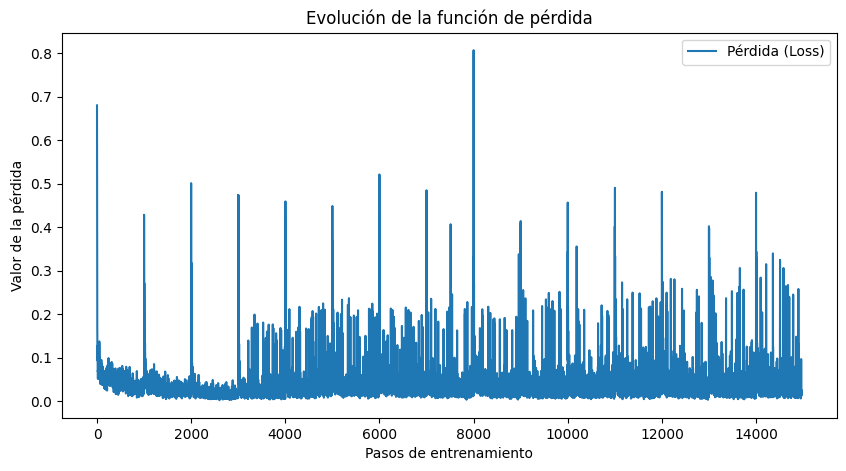

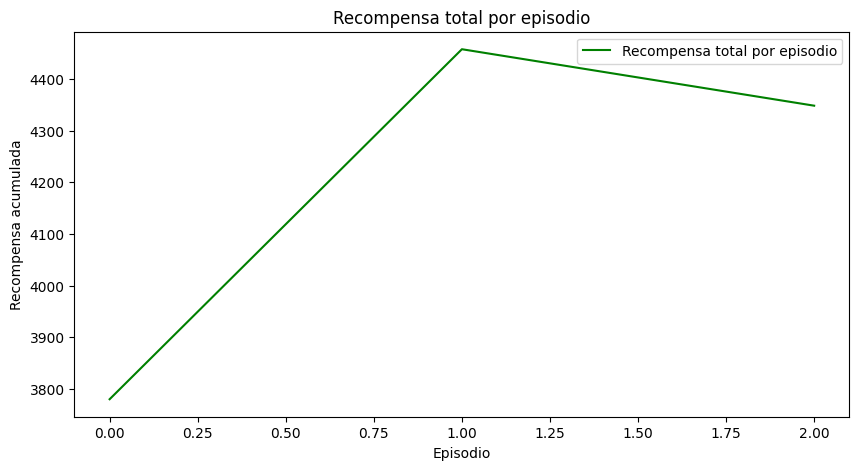

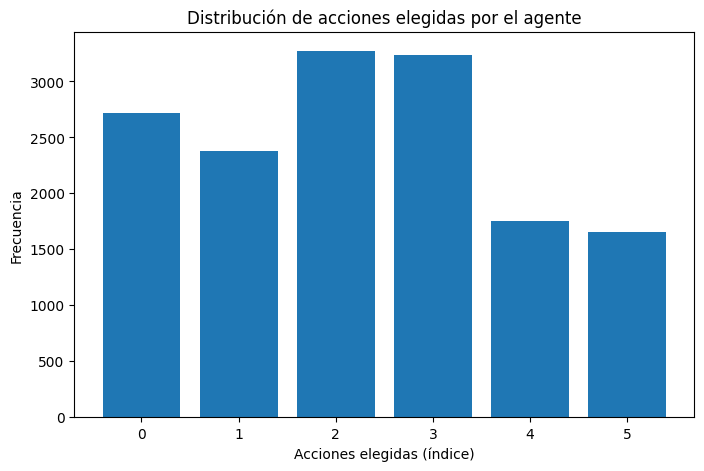

In [ ]:
import matplotlib.pyplot as plt

# evolución de la pérdida
plt.figure(figsize=(10, 5))
plt.plot(trainer.losses, label="Pérdida (Loss)")
plt.xlabel("Pasos de entrenamiento")
plt.ylabel("Valor de la pérdida")
plt.title("Evolución de la función de pérdida")
plt.legend()
plt.show()

# recompensa por episodio
plt.figure(figsize=(10, 5))
plt.plot(trainer.rewards, label="Recompensa total por episodio", color="green")
plt.xlabel("Episodio")
plt.ylabel("Recompensa acumulada")
plt.title("Recompensa total por episodio")
plt.legend()
plt.show()

# histograma de acciones
plt.figure(figsize=(8, 5))
plt.hist(trainer.actions_taken, bins=range(trainer.num_actions + 1), align="left", rwidth=0.8)
plt.xticks(range(trainer.num_actions))
plt.xlabel("Acciones elegidas (índice)")
plt.ylabel("Frecuencia")
plt.title("Distribución de acciones elegidas por el agente")
plt.show()

- El num_actions es 6, este histograma muestra qué tan balanceada es la exploración.
- La curva de loss debería descender suavemente.
- La reward debería subir y estabilizarse si el agente aprende algo útil.

Estos gráficos son hechos con apenas 3 episodios netamente para visualizar, los resultados deberían ser diferentes para los 200 episodios que debría correr el modelo de entreamiento pokemon.

## 7. Conclusión

- Se construyó un agente basado en **DQN** capaz de interactuar con un juego de GameBoy real.
- Se implementaron técnicas clave: `ReplayBuffer`, `Stack de Frames`, detección `game over` por RAM, recompensas basadas en exploración.
- El pipeline es reproducible, modular y adaptable.
- Logramos construir un modelo que juegue Pokemon de forma "aceptable". 

Si bien este proyecto se escapa de los cánones de la carrera de astronomía es posible extrapolar lo que hemos hecho y aprendido a lo largo del desarrollo de este proyecto. Una forma de verlo es si trabajamos en vez de frames del juego (los pantallazos) con imágenes astronómicas o espectros simulados, las acciones del jugador podemos compraralas con las desiciones experminetales del modelo o cómo toma las decisiones en cuanto al movimiento del telescopio y dependiendo de los resultados (calidad de datos, descubrimiento o eficiencia; en vez de una recompensa por exploración o algo como en pokemon) le damos recompensas de acuerdo a su efectividad.

---

## 8. Posibles Mejoras

Una línea de mejora importante sería optimizar la eficiencia del modelo, especialmente en la selección y combinación de ciertas acciones para que su comportamiento sea más coherente en distintas situaciones del juego.  

También se podrían probar configuraciones alternativas de arquitectura y ajuste de hiperparámetros para comparar resultados.  
Otra mejora clave es refinar el sistema de recompensas: explorar más variables internas del juego (además de diálogos, zonas nuevas y estados de game over) para diseñar recompensas más detalladas y alineadas con los objetivos reales del agente.  

Finalmente, disponer de más tiempo de entrenamiento, como dejar el modelo corriendo durante varios días o incluso una semana completa, permitiría aprovechar mejor la capacidad de aprendizaje y alcanzar políticas más estables y generalizables, ya que en nuestro caso al ir probando el código de forma itearada (con intenciones de mejorarlo) lo máximo que podíamos correr cada versión del código era de 1 día (sin contar que a veces nos veíamos interrumpidos por pantallazos azules).


---

## 9. Bibliografía

- PyBoy Documentation: [https://github.com/Baekalfen/PyBoy](https://github.com/Baekalfen/PyBoy)
- TensorFlow 2.x Guide: [https://www.tensorflow.org/guide](https://www.tensorflow.org/guide)
- Pokemon Red Experiments: [https://github.com/PWhiddy/PokemonRedExperiments](https://github.com/PWhiddy/PokemonRedExperiments)
- Training AI to Play Pokemon with Reinforcement Learning: [https://www.youtube.com/watch?v=DcYLT37ImBY&t=88s](https://www.youtube.com/watch?v=DcYLT37ImBY&t=88s) 
- Poke AI GameBoyAdvance: [https://github.com/poke-AI/poke.AI/tree/master](https://github.com/poke-AI/poke.AI/tree/master)

---

### Extra

El código que presentamos en el informe fue nuestro código más exitoso de forma general y en base al cual intentamos hacer múltiples modificaciones para mejorar y alterar el rendimiento del proyecto pero por razones de tiempo y por el la estabilidad de nuestros computadores (muchos pantallazos azules por algún motivo) no logramos refinar ni pulir tantas variantes del código como hubiésemos querido. 

Logramos, eso sí, hacer una variante mucho más enfocada a la exploración de los menús internos del juego y al combate el cual es el código en bruto que presentamos a continuación. Sigue la misma estructura que el código que presenteamos en el informe general pero está menos pulido por el hecho de ser una variable del código principal. Ahora bien, estimamos que es valioso incluirlo por el hecho de que nos permitió explorar otras opciones de afrontar el RL en el juego y nos ayudó a obtener pantallazos del modelo combatiendo, lo cual era muy importante para nosotros; el finalmente poder verlo combatir.

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import cv2
from PIL import Image
from collections import deque
from pyboy import PyBoy
from pyboy.utils import WindowEvent
import random

class DQN(keras.Model):
    def __init__(self, num_actions):
        super(DQN, self).__init__()
        self.conv1 = layers.Conv2D(32, 8, strides=4, activation='relu')
        self.conv2 = layers.Conv2D(64, 4, strides=2, activation='relu')
        self.conv3 = layers.Conv2D(64, 3, strides=1, activation='relu')
        self.flat  = layers.Flatten()
        self.dense = layers.Dense(512, activation='relu') 
        self.out   = layers.Dense(num_actions)

    def call(self, x):
        x = tf.cast(x, tf.float32) / 255.0
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.flat(x)
        x = self.dense(x)
        return self.out(x)

class ReplayBuffer:
    def __init__(self, size, input_shape):
        self.size = size
        self.ptr = 0
        self.count = 0
        self.obs     = np.zeros((size, *input_shape), dtype=np.uint8)
        self.actions = np.zeros(size, dtype=np.int32)
        self.rewards = np.zeros(size, dtype=np.float32)
        self.dones   = np.zeros(size, dtype=bool)

    def store(self, obs, action, reward, done):
        self.obs[self.ptr]     = obs
        self.actions[self.ptr] = action
        self.rewards[self.ptr] = reward
        self.dones[self.ptr]   = done
        self.ptr = (self.ptr + 1) % self.size
        self.count = min(self.count + 1, self.size)

    def sample(self, batch_size):
        idx = np.random.choice(self.count - 1, batch_size, replace=False)
        return (
            self.obs[idx],
            self.actions[idx],
            self.rewards[idx],
            self.obs[idx + 1],
            self.dones[idx]
        )

class PokemonAITrainer:
    def __init__(self, rom_path="POKEMON_RED.gb", screenshot_interval=100):
        self.rom_path = rom_path
        self.screenshot_interval = screenshot_interval
        os.makedirs("screenshots_advanced", exist_ok=True)

        self.frame_shape = (84, 84)
        self.frame_stack = 4
        self.input_shape = (*self.frame_shape, self.frame_stack)

        self.press_actions   = [WindowEvent.PRESS_ARROW_UP, WindowEvent.PRESS_ARROW_DOWN,
                                 WindowEvent.PRESS_ARROW_LEFT, WindowEvent.PRESS_ARROW_RIGHT,
                                 WindowEvent.PRESS_BUTTON_A, WindowEvent.PRESS_BUTTON_B, WindowEvent.PRESS_BUTTON_START]
        self.release_actions = [WindowEvent.RELEASE_ARROW_UP, WindowEvent.RELEASE_ARROW_DOWN,
                                 WindowEvent.RELEASE_ARROW_LEFT, WindowEvent.RELEASE_ARROW_RIGHT,
                                 WindowEvent.RELEASE_BUTTON_A, WindowEvent.RELEASE_BUTTON_B, WindowEvent.RELEASE_BUTTON_START]
        self.num_actions = len(self.press_actions)

        self.lr = 1e-4
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.999
        self.batch_size = 32
        self.update_target_every = 1000
        self.step_count = 0

        self.replay = ReplayBuffer(20000, self.input_shape)

        # Memory Addresses
        self.addr_map_id = 0xD35E
        self.addr_in_battle = 0xD057
        self.addr_party_count = 0xD163
        self.addr_enemy_level = 0xCFE8
        self.addr_game_over = 0xD1F6

        self.visited_maps = set()
        self.prev_party_count = 0

        self.model = DQN(self.num_actions)
        self.target_model = DQN(self.num_actions)
        self.model.build((None, *self.input_shape))
        self.target_model.build((None, *self.input_shape))
        self.optimizer = keras.optimizers.Adam(self.lr)
        self.loss_fn = keras.losses.Huber()

    def skip_intro(self):
        for _ in range(25):
            self.pyboy.send_input(WindowEvent.PRESS_BUTTON_START); self.pyboy.tick()
            self.pyboy.send_input(WindowEvent.RELEASE_BUTTON_START); self.pyboy.tick()
        for _ in range(10000):
            self.pyboy.send_input(WindowEvent.PRESS_BUTTON_A); self.pyboy.tick()
            self.pyboy.send_input(WindowEvent.RELEASE_BUTTON_A); self.pyboy.tick()

    def initialize_game(self):
        if hasattr(self, 'pyboy') and self.pyboy:
            self.pyboy.stop()
        # Corrected PyBoy initialization
        self.pyboy = PyBoy(self.rom_path, window="null") 
        self.pyboy.set_emulation_speed(0)
        self.pyboy.game_wrapper.start_game()
        self.skip_intro()

        self.visited_maps.clear()
        self.prev_party_count = int(self.pyboy.memory[self.addr_party_count])

        for _ in range(random.randint(0, 10)):
            self.pyboy.tick()

        first = self.get_processed_frame()
        self.frame_buffer = deque([first]*self.frame_stack, maxlen=self.frame_stack)

    def get_processed_frame(self):
        raw = self.pyboy.screen.ndarray
        gray = cv2.cvtColor(raw, cv2.COLOR_RGB2GRAY)
        return cv2.resize(gray, self.frame_shape, interpolation=cv2.INTER_AREA)

    def get_state(self):
        frame = self.get_processed_frame()
        self.frame_buffer.append(frame)
        return np.stack(self.frame_buffer, axis=-1)

    def execute(self, action_idx):
        self.pyboy.send_input(self.press_actions[action_idx])
        for _ in range(4): self.pyboy.tick()
        self.pyboy.send_input(self.release_actions[action_idx])
        for _ in range(4): self.pyboy.tick()

    @tf.function
    def train_step(self, obs, acts, rews, next_obs, dones):
        next_q        = self.model(next_obs, training=False)
        next_act      = tf.argmax(next_q, axis=1, output_type=tf.int32)
        next_q_target = self.target_model(next_obs, training=False)
        idx           = tf.stack([tf.range(self.batch_size), next_act], axis=1)
        target        = tf.where(dones, rews, rews + self.gamma * tf.gather_nd(next_q_target, idx))
        with tf.GradientTape() as tape:
            q_vals = self.model(obs, training=True)
            chosen = tf.gather_nd(q_vals, tf.stack([tf.range(self.batch_size), acts], axis=1))
            loss   = self.loss_fn(target, chosen)
        grads = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
        return loss

    def train(self, episodes=500, max_steps=5000):
        for ep in range(episodes):
            self.epsilon = 1.0
            self.initialize_game()
            state        = self.get_state()
            total_reward = 0.0
            steps        = 0
            done         = False

            while not done and steps < max_steps:
                action = self.choose_action(state)
                self.execute(action)

                if steps % self.screenshot_interval == 0:
                    img = Image.fromarray(self.pyboy.screen.ndarray)
                    img.save(f"screenshots_advanced/ep{ep:03d}_step{steps:04d}.png")

                done = (int(self.pyboy.memory[self.addr_game_over]) == 1)
                next_state = self.get_state()

                # Reward Calculation
                reward = 0

                # 1. Exploration Reward
                current_map_id = int(self.pyboy.memory[self.addr_map_id])
                if current_map_id not in self.visited_maps:
                    reward += 10.0 # Major reward for finding a new map
                    self.visited_maps.add(current_map_id)

                # 2. Battle Reward
                if int(self.pyboy.memory[self.addr_in_battle]) == 1:
                    enemy_level = int(self.pyboy.memory[self.addr_enemy_level])
                    reward += float(enemy_level) # Reward for fighting higher level pokemon

                # 3. Capture Reward
                current_party_count = int(self.pyboy.memory[self.addr_party_count])
                if current_party_count > self.prev_party_count:
                    reward += 50.0 # Major reward for capturing a new pokemon
                    self.prev_party_count = current_party_count

                total_reward += reward

                self.replay.store(state, action, reward, done)
                state = next_state
                if self.replay.count > self.batch_size:
                    obs_b, act_b, rew_b, next_b, done_b = self.replay.sample(self.batch_size)
                    obs_b = tf.convert_to_tensor(obs_b)
                    next_b= tf.convert_to_tensor(next_b)
                    self.train_step(obs_b, act_b, rew_b, next_b, done_b)
                    self.step_count += 1
                    if self.step_count % self.update_target_every == 0:
                        self.target_model.set_weights(self.model.get_weights())

                self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
                steps += 1

            print(f"Episode {ep} — Steps: {steps} — Reward: {total_reward:.2f}, Epsilon: {self.epsilon:.3f}")
            if ep and ep % 50 == 0:
                self.model.save_weights(f"dqn_advanced_ep{ep}.weights.h5")
                
        self.model.save_weights("dqn_advanced_final.weights.h5")
        self.pyboy.stop()

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.num_actions)
        q = self.model(np.expand_dims(state, 0), training=False)[0].numpy()
        return int(np.argmax(q))

if __name__ == "__main__":
    trainer = PokemonAITrainer(screenshot_interval=200)
    trainer.train(episodes=200)